## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import json
from tqdm.auto import tqdm

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"[MOBILENETV3-03-EVALUATION] Libraries loaded")
print(f"[MOBILENETV3-03-EVALUATION] Device: {device}")
print(f"[MOBILENETV3-03-EVALUATION] PyTorch version: {torch.__version__}")

[MOBILENETV3-03-EVALUATION] Libraries loaded
[MOBILENETV3-03-EVALUATION] Device: cuda
[MOBILENETV3-03-EVALUATION] PyTorch version: 2.6.0+cu124


## Configuration

In [2]:
# Class configuration
CLASSES = ['Organik', 'Anorganik', 'Lainnya']
NUM_CLASSES = len(CLASSES)

# Input paths
PREPROCESSING_DIR = '/kaggle/input/mobilenetv3-01-preprocessing-output'
TRAINING_DIR = '/kaggle/input/mobilenetv3-02-training-output'
DATASET_BASE_PATH = '/kaggle/input/dataset-sampah'

# Fallbacks for local testing
if not os.path.exists(PREPROCESSING_DIR):
    PREPROCESSING_DIR = './mobilenetv3-01-preprocessing-output'
if not os.path.exists(TRAINING_DIR):
    TRAINING_DIR = './mobilenetv3-02-training-output'
if not os.path.exists(DATASET_BASE_PATH):
    DATASET_BASE_PATH = input("Enter dataset path: ").strip()

# Output directory
OUTPUT_DIR = './mobilenetv3-03-evaluation-output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"[MOBILENETV3-03-EVALUATION] Preprocessing dir: {PREPROCESSING_DIR}")
print(f"[MOBILENETV3-03-EVALUATION] Training dir: {TRAINING_DIR}")
print(f"[MOBILENETV3-03-EVALUATION] Dataset path: {DATASET_BASE_PATH}")
print(f"[MOBILENETV3-03-EVALUATION] Output directory: {OUTPUT_DIR}")

[MOBILENETV3-03-EVALUATION] Preprocessing dir: /kaggle/input/mobilenetv3-01-preprocessing-output
[MOBILENETV3-03-EVALUATION] Training dir: /kaggle/input/mobilenetv3-02-training-output
[MOBILENETV3-03-EVALUATION] Dataset path: /kaggle/input/dataset-sampah
[MOBILENETV3-03-EVALUATION] Output directory: ./mobilenetv3-03-evaluation-output


## Load Test Dataset

In [3]:
print("[MOBILENETV3-03-EVALUATION] Loading test dataset...")

test_df = pd.read_csv(f'{PREPROCESSING_DIR}/test_dataset.csv')

print(f"[MOBILENETV3-03-EVALUATION] Test data loaded:")
print(f"  Total samples: {len(test_df):,}")

print(f"\nClass distribution:")
for i, class_name in enumerate(CLASSES):
    count = (test_df['class_idx'] == i).sum()
    print(f"  {class_name}: {count} samples ({count/len(test_df)*100:.1f}%)")

print(f"\nDataFrame preview:")
print(test_df.head())

[MOBILENETV3-03-EVALUATION] Loading test dataset...
[MOBILENETV3-03-EVALUATION] Test data loaded:
  Total samples: 2,700

Class distribution:
  Organik: 900 samples (33.3%)
  Anorganik: 900 samples (33.3%)
  Lainnya: 900 samples (33.3%)

DataFrame preview:
                                          image_path class_name  class_idx
0  /kaggle/input/dataset-sampah/Organik/Organik43...    Organik          0
1  /kaggle/input/dataset-sampah/Organik/Organik48...    Organik          0
2  /kaggle/input/dataset-sampah/Anorganik/Anorgan...  Anorganik          1
3  /kaggle/input/dataset-sampah/Organik/Organik95...    Organik          0
4  /kaggle/input/dataset-sampah/Lainnya/Lainnya46...    Lainnya          2


## Image Transforms (Same as Training)

In [4]:
# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Test transform (NO augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("[MOBILENETV3-03-EVALUATION] Test transform configured:")
print("  1. Resize(224, 224)")
print("  2. ToTensor() → [0-255] to [0-1]")
print("  3. Normalize(ImageNet mean/std)")
print("  (NO augmentation)")

[MOBILENETV3-03-EVALUATION] Test transform configured:
  1. Resize(224, 224)
  2. ToTensor() → [0-255] to [0-1]
  3. Normalize(ImageNet mean/std)
  (NO augmentation)


## Custom Dataset Class

In [5]:
class WasteDataset(Dataset):
    """
    Custom dataset untuk load images dari CSV paths.
    """
    def __init__(self, df, dataset_base_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.dataset_base_path = dataset_base_path
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image from path
        img_path = row['image_path']
        
        # Handle path (Kaggle vs local)
        if not os.path.exists(img_path):
            # Try relative path from dataset_base_path
            class_name = row['class_name']
            filename = os.path.basename(img_path)
            img_path = os.path.join(self.dataset_base_path, class_name, filename)
        
        # Load and convert to RGB
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = row['class_idx']
        
        return image, label, img_path

# Create test dataset and dataloader
test_dataset = WasteDataset(test_df, DATASET_BASE_PATH, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"[MOBILENETV3-03-EVALUATION] Test DataLoader created:")
print(f"  {len(test_loader)} batches ({len(test_dataset)} samples)")

[MOBILENETV3-03-EVALUATION] Test DataLoader created:
  85 batches (2700 samples)


## Load Trained MobileNetV3 Model

In [6]:
class MobileNetV3Classifier(nn.Module):
    """
    MobileNetV3-Large dengan custom classifier untuk 3 classes.
    """
    def __init__(self, num_classes=3, pretrained=False):
        super().__init__()
        
        # Load MobileNetV3-Large
        self.mobilenet = models.mobilenet_v3_large(pretrained=pretrained)
        
        # Replace classifier
        in_features = self.mobilenet.classifier[3].in_features
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        return self.mobilenet(x)

# Initialize model
print("[MOBILENETV3-03-EVALUATION] Loading trained model...")
model = MobileNetV3Classifier(num_classes=NUM_CLASSES, pretrained=False)

# Load best weights
model_path = f'{TRAINING_DIR}/best_mobilenetv3_model.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

model_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"[MOBILENETV3-03-EVALUATION] Model loaded:")
print(f"  Model file: best_mobilenetv3_model.pth ({model_size:.2f} MB)")
print(f"  Device: {device}")
print(f"  Mode: eval()")

[MOBILENETV3-03-EVALUATION] Loading trained model...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[MOBILENETV3-03-EVALUATION] Model loaded:
  Model file: best_mobilenetv3_model.pth (16.25 MB)
  Device: cuda
  Mode: eval()


## Evaluate Model on Test Set

In [7]:
print("\n[MOBILENETV3-03-EVALUATION] Evaluating model on test set...")
print("="*60)

all_preds = []
all_labels = []
all_probs = []
all_paths = []

with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc='Evaluating'):
        images = images.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Get predictions and probabilities
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("\n[MOBILENETV3-03-EVALUATION] Evaluation complete!")
print(f"  Evaluated samples: {len(all_preds):,}")


[MOBILENETV3-03-EVALUATION] Evaluating model on test set...


Evaluating:   0%|          | 0/85 [00:00<?, ?it/s]


[MOBILENETV3-03-EVALUATION] Evaluation complete!
  Evaluated samples: 2,700


## Calculate Metrics

In [8]:
print("\n[MOBILENETV3-03-EVALUATION] Calculating metrics...")

# Overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

# Per-class metrics
precision_per_class = precision_score(all_labels, all_preds, average=None)
recall_per_class = recall_score(all_labels, all_preds, average=None)
f1_per_class = f1_score(all_labels, all_preds, average=None)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Confidence statistics
confidences = all_probs.max(axis=1)

print(f"\n[MOBILENETV3-03-EVALUATION] Test Set Performance:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nPer-class metrics:")
for i, class_name in enumerate(CLASSES):
    print(f"  {class_name}:")
    print(f"    Precision: {precision_per_class[i]:.4f}")
    print(f"    Recall:    {recall_per_class[i]:.4f}")
    print(f"    F1-Score:  {f1_per_class[i]:.4f}")

print(f"\nConfidence statistics:")
print(f"  Mean: {confidences.mean():.4f}")
print(f"  Std:  {confidences.std():.4f}")
print(f"  Min:  {confidences.min():.4f}")
print(f"  Max:  {confidences.max():.4f}")


[MOBILENETV3-03-EVALUATION] Calculating metrics...

[MOBILENETV3-03-EVALUATION] Test Set Performance:
  Accuracy:  0.9744 (97.44%)
  Precision: 0.9745
  Recall:    0.9744
  F1-Score:  0.9744

Per-class metrics:
  Organik:
    Precision: 0.9912
    Recall:    0.9956
    F1-Score:  0.9933
  Anorganik:
    Precision: 0.9762
    Recall:    0.9567
    F1-Score:  0.9663
  Lainnya:
    Precision: 0.9562
    Recall:    0.9711
    F1-Score:  0.9636

Confidence statistics:
  Mean: 0.9892
  Std:  0.0531
  Min:  0.4899
  Max:  1.0000


## Confusion Matrix Visualization

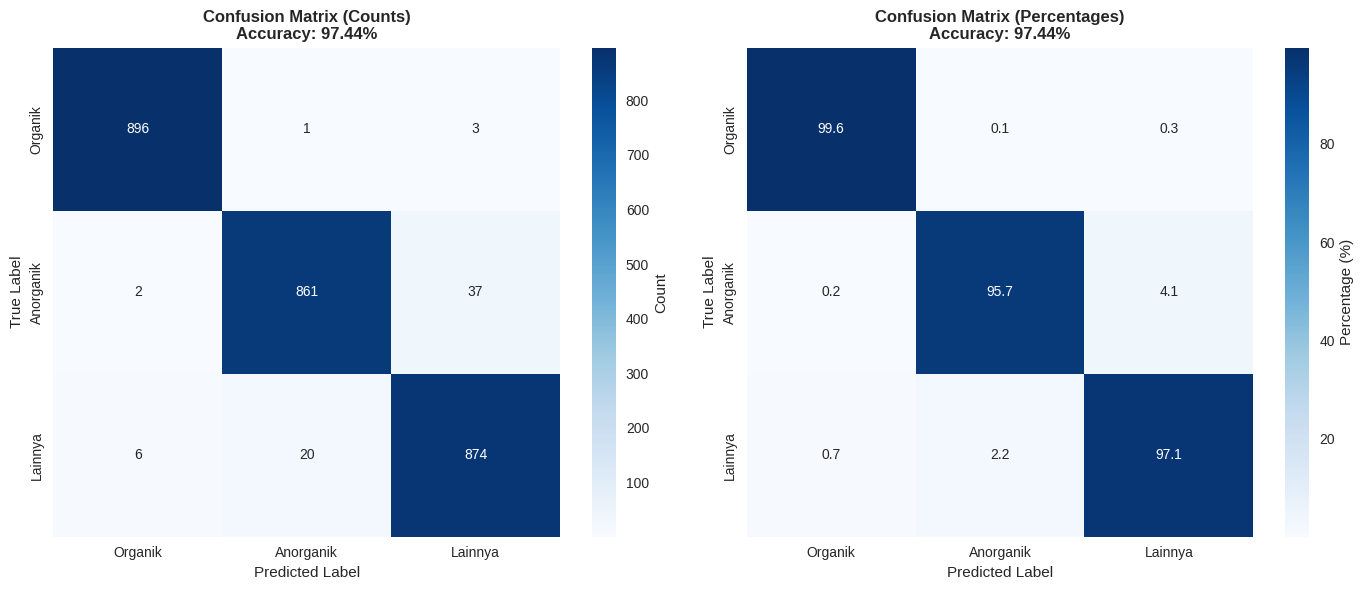

[MOBILENETV3-03-EVALUATION] Confusion matrix saved to ./mobilenetv3-03-evaluation-output/confusion_matrix.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix (counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Confusion Matrix (Counts)\nAccuracy: {accuracy:.2%}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Confusion matrix (percentages)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], cbar_kws={'label': 'Percentage (%)'})
axes[1].set_title(f'Confusion Matrix (Percentages)\nAccuracy: {accuracy:.2%}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[MOBILENETV3-03-EVALUATION] Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")

## Confidence Distribution

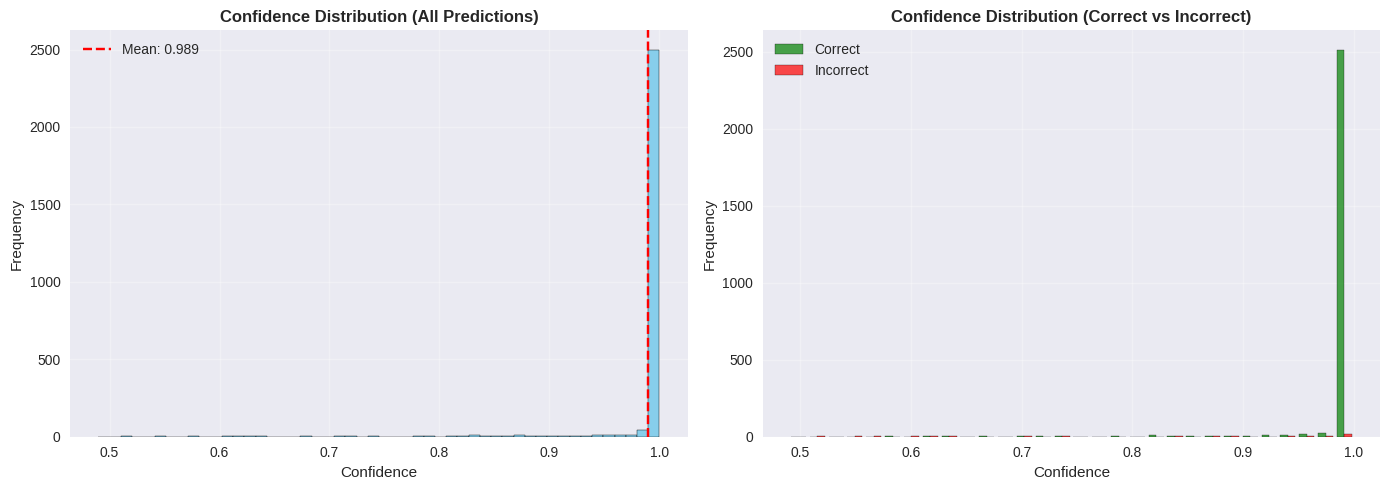

[MOBILENETV3-03-EVALUATION] Confidence distribution saved to ./mobilenetv3-03-evaluation-output/confidence_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall confidence distribution
axes[0].hist(confidences, bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(confidences.mean(), color='red', linestyle='--', 
                label=f'Mean: {confidences.mean():.3f}')
axes[0].set_title('Confidence Distribution (All Predictions)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confidence by correctness
correct_mask = all_preds == all_labels
correct_conf = confidences[correct_mask]
incorrect_conf = confidences[~correct_mask]

axes[1].hist([correct_conf, incorrect_conf], bins=30, 
             label=['Correct', 'Incorrect'],
             color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_title('Confidence Distribution (Correct vs Incorrect)', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[MOBILENETV3-03-EVALUATION] Confidence distribution saved to {OUTPUT_DIR}/confidence_distribution.png")

## Classification Report

In [11]:
print("\n[MOBILENETV3-03-EVALUATION] Detailed Classification Report:")
print("="*60)

report = classification_report(all_labels, all_preds, target_names=CLASSES, digits=4)
print(report)

# Save report
with open(f'{OUTPUT_DIR}/classification_report.txt', 'w') as f:
    f.write("MobileNetV3 Direct Classification Report\n")
    f.write("="*60 + "\n\n")
    f.write(report)

print(f"[MOBILENETV3-03-EVALUATION] Classification report saved to {OUTPUT_DIR}/classification_report.txt")


[MOBILENETV3-03-EVALUATION] Detailed Classification Report:
              precision    recall  f1-score   support

     Organik     0.9912    0.9956    0.9933       900
   Anorganik     0.9762    0.9567    0.9663       900
     Lainnya     0.9562    0.9711    0.9636       900

    accuracy                         0.9744      2700
   macro avg     0.9745    0.9744    0.9744      2700
weighted avg     0.9745    0.9744    0.9744      2700

[MOBILENETV3-03-EVALUATION] Classification report saved to ./mobilenetv3-03-evaluation-output/classification_report.txt


## Save Predictions

In [12]:
print(f"\n[MOBILENETV3-03-EVALUATION] Saving predictions to: {OUTPUT_DIR}")

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'image_path': all_paths,
    'true_label': all_labels,
    'true_class': [CLASSES[i] for i in all_labels],
    'pred_label': all_preds,
    'pred_class': [CLASSES[i] for i in all_preds],
    'confidence': confidences,
    'organik_prob': all_probs[:, 0],
    'anorganik_prob': all_probs[:, 1],
    'lainnya_prob': all_probs[:, 2],
    'correct': all_preds == all_labels
})

predictions_df.to_csv(f'{OUTPUT_DIR}/test_predictions.csv', index=False)
print(f"  ✓ test_predictions.csv ({len(predictions_df):,} rows)")

# Save metrics
metrics_summary = {
    'model': 'MobileNetV3-Large (Direct Classification)',
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'precision_per_class': precision_per_class.tolist(),
    'recall_per_class': recall_per_class.tolist(),
    'f1_per_class': f1_per_class.tolist(),
    'confidence_mean': float(confidences.mean()),
    'confidence_std': float(confidences.std()),
    'confidence_min': float(confidences.min()),
    'confidence_max': float(confidences.max()),
    'correct_predictions': int((all_preds == all_labels).sum()),
    'incorrect_predictions': int((all_preds != all_labels).sum())
}

with open(f'{OUTPUT_DIR}/evaluation_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(f"  ✓ evaluation_metrics.json")

# List all saved files
print(f"\n[MOBILENETV3-03-EVALUATION] All files saved:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    file_path = os.path.join(OUTPUT_DIR, file)
    if os.path.isfile(file_path):
        file_size = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  {file} ({file_size:.2f} MB)")


[MOBILENETV3-03-EVALUATION] Saving predictions to: ./mobilenetv3-03-evaluation-output
  ✓ test_predictions.csv (2,700 rows)
  ✓ evaluation_metrics.json

[MOBILENETV3-03-EVALUATION] All files saved:
  classification_report.txt (0.00 MB)
  confidence_distribution.png (0.05 MB)
  confusion_matrix.png (0.08 MB)
  evaluation_metrics.json (0.00 MB)
  test_predictions.csv (0.32 MB)


## Sample Predictions Analysis

In [13]:
print("\n[MOBILENETV3-03-EVALUATION] Sample Predictions Analysis:")
print("="*60)

# Top 10 most confident correct predictions
top_correct = predictions_df[predictions_df['correct']].nlargest(10, 'confidence')
print("\nTop 10 Most Confident CORRECT Predictions:")
print(top_correct[['true_class', 'pred_class', 'confidence']].to_string(index=False))

# Top 10 most confident incorrect predictions
if (~predictions_df['correct']).any():
    top_incorrect = predictions_df[~predictions_df['correct']].nlargest(10, 'confidence')
    print("\nTop 10 Most Confident INCORRECT Predictions:")
    print(top_incorrect[['true_class', 'pred_class', 'confidence']].to_string(index=False))
else:
    print("\nNo incorrect predictions! Perfect accuracy!")

# Low confidence predictions
low_conf = predictions_df.nsmallest(10, 'confidence')
print("\nTop 10 Lowest Confidence Predictions:")
print(low_conf[['true_class', 'pred_class', 'confidence', 'correct']].to_string(index=False))


[MOBILENETV3-03-EVALUATION] Sample Predictions Analysis:

Top 10 Most Confident CORRECT Predictions:
true_class pred_class  confidence
   Organik    Organik         1.0
   Organik    Organik         1.0
 Anorganik  Anorganik         1.0
   Organik    Organik         1.0
   Organik    Organik         1.0
   Organik    Organik         1.0
   Organik    Organik         1.0
 Anorganik  Anorganik         1.0
   Organik    Organik         1.0
   Organik    Organik         1.0

Top 10 Most Confident INCORRECT Predictions:
true_class pred_class  confidence
 Anorganik    Lainnya    0.999838
   Lainnya  Anorganik    0.999337
   Lainnya    Organik    0.999330
 Anorganik    Lainnya    0.999275
 Anorganik    Lainnya    0.999067
 Anorganik    Lainnya    0.996304
   Lainnya  Anorganik    0.996065
 Anorganik    Lainnya    0.995746
 Anorganik    Lainnya    0.994957
 Anorganik    Lainnya    0.993606

Top 10 Lowest Confidence Predictions:
true_class pred_class  confidence  correct
   Lainnya  Anorganik 

## Evaluation Summary Report

In [14]:
summary = f"""
========================================
MOBILENETV3 DIRECT - 03. EVALUATION SUMMARY - JakOlah
========================================

Model: MobileNetV3-Large (Direct Classification)

Test Dataset:
  Total samples: {len(test_df):,}
  Classes: {len(CLASSES)} ({', '.join(CLASSES)})

Class Distribution:
"""

for i, class_name in enumerate(CLASSES):
    count = (all_labels == i).sum()
    pct = count / len(all_labels) * 100
    summary += f"  {class_name}: {count} ({pct:.1f}%)\n"

summary += f"""
Overall Performance:
  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
  Precision: {precision:.4f}
  Recall:    {recall:.4f}
  F1-Score:  {f1:.4f}

Per-Class Performance:
"""

for i, class_name in enumerate(CLASSES):
    summary += f"""  {class_name}:
    Precision: {precision_per_class[i]:.4f}
    Recall:    {recall_per_class[i]:.4f}
    F1-Score:  {f1_per_class[i]:.4f}
"""

summary += f"""
Confidence Statistics:
  Mean: {confidences.mean():.4f}
  Std:  {confidences.std():.4f}
  Range: [{confidences.min():.4f}, {confidences.max():.4f}]

Prediction Accuracy:
  Correct:   {(all_preds == all_labels).sum():,} ({(all_preds == all_labels).sum()/len(all_labels)*100:.1f}%)
  Incorrect: {(all_preds != all_labels).sum():,} ({(all_preds != all_labels).sum()/len(all_labels)*100:.1f}%)

Output Files:
  ✓ confusion_matrix.png
  ✓ confidence_distribution.png
  ✓ classification_report.txt
  ✓ test_predictions.csv
  ✓ evaluation_metrics.json

Pipeline Comparison (Test Accuracy):
  SVM Pipeline: Check 04-evaluation-step.ipynb from SVM pipeline
  MobileNetV3 Direct: {accuracy:.4f} ({accuracy*100:.2f}%)

Key Advantages of MobileNetV3 Direct:
  1. End-to-end learning (better feature adaptation)
  2. Direct probability outputs (no need for SVM calibration)
  3. Simpler deployment (single PyTorch model)
  4. Gradient-based optimization throughout entire network

Production Recommendations:
  - Monitor confidence distribution in production
  - Retrain if accuracy drops below {accuracy*0.9:.2f}
  - Collect misclassified samples for model improvement
  - Consider ensemble with SVM model for critical applications

Deployment Instructions:
  1. Load model architecture: model = MobileNetV3Classifier(num_classes={NUM_CLASSES})
  2. Load trained weights: model.load_state_dict(torch.load('best_mobilenetv3_model.pth'))
  3. Set to eval mode: model.eval()
  4. Preprocess image: image = transform(PIL_image)
  5. Inference: output = model(image.unsqueeze(0))
  6. Get probabilities: probs = torch.softmax(output, dim=1)

========================================
EVALUATION COMPLETE ✅
========================================
"""

print(summary)

with open(f'{OUTPUT_DIR}/evaluation_summary.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print(f"[MOBILENETV3-03-EVALUATION] Summary saved to {OUTPUT_DIR}/evaluation_summary.md")
print(f"[MOBILENETV3-03-EVALUATION] ✅ COMPLETED")


MOBILENETV3 DIRECT - 03. EVALUATION SUMMARY - JakOlah

Model: MobileNetV3-Large (Direct Classification)

Test Dataset:
  Total samples: 2,700
  Classes: 3 (Organik, Anorganik, Lainnya)

Class Distribution:
  Organik: 900 (33.3%)
  Anorganik: 900 (33.3%)
  Lainnya: 900 (33.3%)

Overall Performance:
  Accuracy:  0.9744 (97.44%)
  Precision: 0.9745
  Recall:    0.9744
  F1-Score:  0.9744

Per-Class Performance:
  Organik:
    Precision: 0.9912
    Recall:    0.9956
    F1-Score:  0.9933
  Anorganik:
    Precision: 0.9762
    Recall:    0.9567
    F1-Score:  0.9663
  Lainnya:
    Precision: 0.9562
    Recall:    0.9711
    F1-Score:  0.9636

Confidence Statistics:
  Mean: 0.9892
  Std:  0.0531
  Range: [0.4899, 1.0000]

Prediction Accuracy:
  Correct:   2,631 (97.4%)
  Incorrect: 69 (2.6%)

Output Files:
  ✓ confusion_matrix.png
  ✓ confidence_distribution.png
  ✓ classification_report.txt
  ✓ test_predictions.csv
  ✓ evaluation_metrics.json

Pipeline Comparison (Test Accuracy):
  SVM Pip

## Download Output (Kaggle)

In [15]:
import shutil

# Create zip file of all outputs
zip_filename = 'mobilenetv3-03-evaluation-output'
shutil.make_archive(zip_filename, 'zip', OUTPUT_DIR)

print(f"[MOBILENETV3-03-EVALUATION] Output zipped to: {zip_filename}.zip")
print(f"  File size: {os.path.getsize(f'{zip_filename}.zip') / (1024*1024):.2f} MB")
print(f"\n💾 Download {zip_filename}.zip dari Kaggle output panel")
print(f"\nContents: Confusion matrix, confidence distribution, classification report, predictions")

[MOBILENETV3-03-EVALUATION] Output zipped to: mobilenetv3-03-evaluation-output.zip
  File size: 0.16 MB

💾 Download mobilenetv3-03-evaluation-output.zip dari Kaggle output panel

Contents: Confusion matrix, confidence distribution, classification report, predictions
